In [ ]:
%pip install langgraph langchain langchain-mcp-adapters langchain-openai "pydantic[email]" mcp fastmcp "fastmcp[tasks]"

In [1]:
import langgraph
import importlib.metadata

version = importlib.metadata.version("langgraph")
print(f"LangGraph Version: {version}")

LangGraph Version: 1.1.6


##### Work With State Graphs
LangGraph is all about implementing LLM applications as directed graphs. You can think of a directed graph as a sequence of instructions composed of nodes and edges, that tell you how to complete a task. 

In LangGraph, 
- `nodes` represent actions that your graph can take, such as calling a function, and
- `edges` tell you which node to go to next.

To understand this better, take a look at this directed graph:

![](./notice_extraction_graph.png)

##### LangChain Chains and Their Limitations
Suppose you work for a large real estate development company. Your company receives hundreds of emails a day from regulatory entities and other organizations regarding active construction sites. For instance, your company might receive a notice from an inspector saying that a construction site doesn’t comply with safety regulations.

Your job is to build a tool that can read these emails, extract critical information from them, and notify the correct internal team who will take action. The first step you’ll take to accomplish this is to build a LangChain chain that uses an LLM to extract structured fields from a regulatory notice email. You start by defining a Pydantic BaseModel that describes all the fields you want to extract from the email:



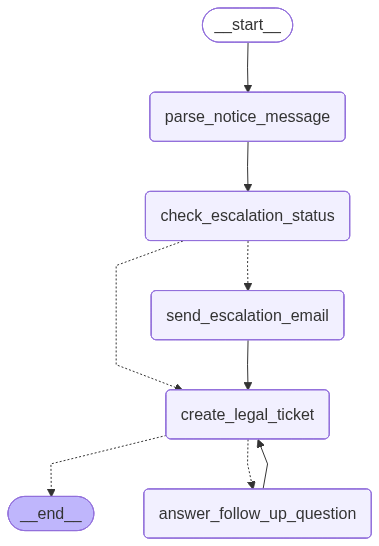

In [3]:
from com.example.agentic.graphs.notice_extraction import NOTICE_EXTRACTION_GRAPH
from IPython.display import Image, display

image_data = NOTICE_EXTRACTION_GRAPH.get_graph().draw_mermaid_png()
# with open("notice_extraction_graph.png", mode="wb") as f:
#     f.write(image_data)

#
try:
  display(Image(image_data))
except Exception:
  pass


In [5]:
from com.example.agentic.graphs.notice_extraction import NOTICE_EXTRACTION_GRAPH, NoticeEmailExtract
from com.example.agentic.graphs.example_emails import EMAILS

initial_state = {
     "notice_message": EMAILS[0],
     "notice_email_extract": None,
     "escalation_text_criteria": """There's a risk of fire or water damage at the site""",
     "escalation_dollar_criteria": 100_000,
     "requires_escalation": False,
     "escalation_emails": ["brog@abc.com", "bigceo@company.com"],
}

final_state = NOTICE_EXTRACTION_GRAPH.invoke(initial_state)




2026-04-07 11:24:00,820 - INFO - Parsing notice...


2026-04-07 11:24:02,051 - INFO - Determining escalation status...
2026-04-07 11:24:02,270 - INFO - No escalation needed
2026-04-07 11:24:02,272 - INFO - Creating legal ticket for notice...
2026-04-07 11:24:04,273 - INFO - Legal ticket created!


In [7]:
import datetime

final_state["notice_email_extract"]

NoticeEmailExtract(
    date_of_notice=datetime.date(2024, 10, 15),
    entity_name='Occupational Safety and Health Administration (OSHA)',
    entity_phone='(555) 123-4567',
    entity_email='compliance.osha@osha.gov',
    project_id=111232345,
    site_location='123 Main Street, Dallas, TX',
    violation_type='Lack of fall protection, Unsafe scaffolding setup, Inadequate personal protective equipment (PPE)',
    required_changes='Install guardrails and fall arrest systems on all scaffolding over 10 feet. Conduct an inspection of all \
        scaffolding structures and reinforce unstable sections. Ensure all workers on-site are provided with necessary PPE and conduct \
        safety training on proper usage.',
    compliance_deadline=datetime.date(2024, 11, 10),
    max_potential_fine=25000.0
)

final_state["requires_escalation"]

False

##### Test Your Graph Agent

In [9]:
from com.example.agentic.graphs.email_agent import email_agent_graph
from com.example.agentic.graphs.example_emails import EMAILS

message_1 = {"messages": [("human", EMAILS[1])]}
for chunk in email_agent_graph.stream(message_1, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================


    From: debby@stack.com
    Hey Betsy,
    Here's your invoice for $1000 for the cookies you ordered.
    
================================== Ai Message ==================================

It looks like you’ve received an invoice from Debby at Stack.com.  
Would you like me to forward this to the finance department for processing, or is there something else you’d like me to do with it?


In [10]:
message_2 = {"messages": [("human", EMAILS[2])]}
for chunk in email_agent_graph.stream(message_2, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================


    From: tdavid@companyxyz.com
    Hi Paul,
    We have an issue with the HVAC system your team installed in
    apartment 1235. We'd like to request maintenance or a refund.
    Thanks,
    Terrance
    


2026-04-07 11:31:12,561 - INFO - Forwarding the email to maintenance@companyxyz.com...


================================== Ai Message ==================================
Tool Calls:
  forward_email (fc_27083c02-b515-4c15-9935-a3e034d63022)
 Call ID: fc_27083c02-b515-4c15-9935-a3e034d63022
  Args:
    email_message: From: tdavid@companyxyz.com
Hi Paul,
We have an issue with the HVAC system your team installed in apartment 1235. We'd like to request maintenance or a refund.
Thanks,
Terrance
    send_to_email: maintenance@companyxyz.com


2026-04-07 11:31:14,562 - INFO - Email forwarded!


================================= Tool Message =================================
Name: forward_email

true
================================== Ai Message ==================================

Your request has been forwarded to the maintenance team for further action. If you have any additional details or need further assistance, please let us know.


In [11]:
escalation_criteria = """"There's an immediate risk of electrical, water, or fire damage"""
message_with_criteria = f"""
The escalation criteria is: {escalation_criteria}

Here's the email:

{EMAILS[3]}
"""

message_3 = {"messages": [("human", message_with_criteria)]}
for chunk in email_agent_graph.stream(message_3, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================


The escalation criteria is: "There's an immediate risk of electrical, water, or fire damage

Here's the email:


    Date: January 10, 2025
    From: City of Los Angeles Building and Safety Department
    To: West Coast Development, project 345678123 - Sunset Luxury
    Condominiums
    Location: Los Angeles, CA
    Following an inspection of your site at 456 Sunset Boulevard, we have
    identified the following building code violations:
    Electrical Wiring: Exposed wiring was found in the underground parking
    garage, posing a safety hazard. Fire Safety: Insufficient fire
    extinguishers were available across multiple floors of the structure
    under construction.
    Structural Integrity: The temporary support beams in the eastern wing
    do not meet the load-bearing standards specified in local building
    codes.
    Required Corrective Actions:
    Replace or properly secure exposed wiring 

2026-04-07 11:33:48,231 - INFO - Calling the email notice extraction graph...
2026-04-07 11:33:48,235 - INFO - Parsing notice...


================================== Ai Message ==================================
Tool Calls:
  extract_notice_data (fc_12aac069-ef13-4e72-8162-f4daeee1ec2d)
 Call ID: fc_12aac069-ef13-4e72-8162-f4daeee1ec2d
  Args:
    email: Date: January 10, 2025
From: City of Los Angeles Building and Safety Department
To: West Coast Development, project 345678123 - Sunset Luxury
Condominiums
Location: Los Angeles, CA
Following an inspection of your site at 456 Sunset Boulevard, we have
identified the following building code violations:
Electrical Wiring: Exposed wiring was found in the underground parking
garage, posing a safety hazard. Fire Safety: Insufficient fire
extinguishers were available across multiple floors of the structure
under construction.
Structural Integrity: The temporary support beams in the eastern wing
do not meet the load-bearing standards specified in local building
codes.
Required Corrective Actions:
Replace or properly secure exposed wiring to meet electrical safety
standard

2026-04-07 11:33:49,206 - INFO - Determining escalation status...
2026-04-07 11:33:49,424 - INFO - Escalation needed!
2026-04-07 11:33:49,425 - INFO - Sending escalation emails...
2026-04-07 11:33:50,426 - INFO - Escalation email sent to brog@abc.com
2026-04-07 11:33:51,427 - INFO - Escalation email sent to bigceo@company.com
2026-04-07 11:33:51,430 - INFO - Creating legal ticket for notice...
2026-04-07 11:33:53,430 - INFO - Legal ticket created!


================================= Tool Message =================================
Name: extract_notice_data

entity_name='City of Los Angeles Building and Safety Department' entity_phone='(555) 456-7890' entity_email='inspections@lacity.gov' project_id=345678123 site_location='456 Sunset Boulevard, Los Angeles, CA' violation_type='Electrical Wiring, Fire Safety, Structural Integrity' required_changes='Replace or properly secure exposed wiring to meet electrical safety standards. Install additional fire extinguishers in compliance with fire code requirements. Reinforce or replace temporary support beams to ensure structural stability.' max_potential_fine=None date_of_notice=datetime.date(2025, 1, 10) compliance_deadline=datetime.date(2025, 2, 5)


2026-04-07 11:33:54,172 - INFO - Forwarding the email to compliance@westcoastdev.com...


================================== Ai Message ==================================
Tool Calls:
  forward_email (fc_78ae92be-bef7-4f00-b399-a63be9aae868)
 Call ID: fc_78ae92be-bef7-4f00-b399-a63be9aae868
  Args:
    email_message: Date: January 10, 2025
From: City of Los Angeles Building and Safety Department
To: West Coast Development, project 345678123 - Sunset Luxury
Condominiums
Location: Los Angeles, CA
Following an inspection of your site at 456 Sunset Boulevard, we have
identified the following building code violations:
Electrical Wiring: Exposed wiring was found in the underground parking
garage, posing a safety hazard. Fire Safety: Insufficient fire
extinguishers were available across multiple floors of the structure
under construction.
Structural Integrity: The temporary support beams in the eastern wing
do not meet the load-bearing standards specified in local building
codes.
Required Corrective Actions:
Replace or properly secure exposed wiring to meet electrical safety
standa

2026-04-07 11:33:56,173 - INFO - Email forwarded!


================================= Tool Message =================================
Name: forward_email

true
================================== Ai Message ==================================

The notice has been forwarded to the compliance team for immediate action.
